[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhiyunli/cpsc5610-labs/blob/main/week8/lab_lstm_gru_conv.ipynb)

# Week 8 Lab 2: LSTM, GRU, and Convolutional Sequence Models

**CPSC 5610 — Deep Learning**

In **Lab 1** you trained a plain `nn.RNN` on a synthetic price series. Here we keep
**the exact same data and evaluation** and swap in smarter cells and convolutional
alternatives, so every number is directly comparable.

By the end of this lab you will be able to:

1. Add **LayerNorm** inside a recurrent cell and measure its effect (ablation).
2. Train **LSTM** and **GRU** forecasters and compare them to the plain RNN.
3. Build a **causal Conv1D** forecaster and understand why we left-pad.
4. Stack **dilated** causal convolutions for an exponentially larger receptive field.
5. Read a side-by-side scoreboard of **eight** models on one forecasting task.

> This notebook embeds figures from the Lecture 2 slides; they live in `lab2_slides/`
> next to this file.

## 1. Setup

Same stack as Lab 1: **PyTorch**, **NumPy**, **Matplotlib**. Everything runs on CPU in a
few minutes. We seed for reproducibility and import `torch.nn.functional` (we'll need
`F.pad` and `F.relu` for the convolutional models).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 5610
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)

PyTorch 2.10.0+cpu | device: cpu


## 2. The dataset — identical to Lab 1

We regenerate the **same** synthetic daily price series (level + yearly cycle + weekly
cycle + AR(1) momentum + noise), split it **chronologically** 70 / 15 / 15, and
standardize with **train statistics only**. Because the seed and recipe match Lab 1,
the forecasting task is the same — only the models change.

$$
\text{price}(t) = L + c\sin(2\pi t/252) + d\sin(2\pi t/5) + r_t + \sigma\varepsilon_t,
\qquad r_t = \rho\,r_{t-1} + \eta_t
$$

In [2]:
def make_stock_series(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    level  = 100.0
    yearly =  6.0 * np.sin(2 * np.pi * t / 252)
    weekly =  1.5 * np.sin(2 * np.pi * t / 5)
    rho = 0.90                                  # AR(1) momentum
    eps = rng.standard_normal(n) * 0.5
    r = np.zeros(n)
    for i in range(1, n):
        r[i] = rho * r[i-1] + eps[i]
    noise = rng.standard_normal(n) * 0.5
    price = level + yearly + weekly + r + noise
    return t, price.astype(np.float32)

t, price = make_stock_series(n=2000, seed=SEED)

# chronological split (never shuffle a time series before splitting)
n = len(price)
i_train, i_val = int(0.70 * n), int(0.85 * n)
train, val, test = price[:i_train], price[i_train:i_val], price[i_val:]

# standardize with TRAIN statistics only
mu, sd = train.mean(), train.std()
train_s = (train - mu) / sd
val_s   = (val   - mu) / sd
test_s  = (test  - mu) / sd
print('sizes  train/val/test:', len(train), len(val), len(test))
print(f'train mean={mu:.2f}  std={sd:.2f}')

sizes  train/val/test: 1400 300 300
train mean=100.36  std=4.26


### Sliding-window dataset and shared training helpers

A forecasting example is a **(window, next value)** pair: given the past `W` standardized
values, predict the next one (single-step). Every model in this lab is trained and scored
with the **same** `train_model` / `eval_mae` helpers, and we report **MAE in price units**
(via `unstd`) so the numbers are interpretable. A shared `scoreboard` dict collects results.

In [3]:
class WindowDataset(Dataset):
    """Single-step: window of length W -> next value."""
    def __init__(self, series, window=50):
        self.series, self.W = series, window
    def __len__(self):
        return len(self.series) - self.W
    def __getitem__(self, i):
        x = self.series[i : i + self.W]
        y = self.series[i + self.W]
        return (torch.from_numpy(x).unsqueeze(-1),          # (W, 1)
                torch.tensor([y], dtype=torch.float32))     # (1,)

W, BATCH, HIDDEN, EPOCHS = 50, 32, 32, 15

dl_train = DataLoader(WindowDataset(train_s, W), batch_size=BATCH, shuffle=True)
dl_val   = DataLoader(WindowDataset(val_s,   W), batch_size=BATCH, shuffle=False)
dl_test  = DataLoader(WindowDataset(test_s,  W), batch_size=BATCH, shuffle=False)

def unstd(y):
    return y * sd + mu

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def train_model(model, dl_tr, dl_va, epochs=EPOCHS, lr=1e-3, verbose=False):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    hist = {'tr': [], 'va': []}
    for ep in range(epochs):
        model.train(); tr, ntr = 0.0, 0
        for x, y in dl_tr:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = lossf(model(x), y)
            loss.backward(); opt.step()
            tr += loss.item() * y.shape[0]; ntr += y.shape[0]
        model.eval(); va, nva = 0.0, 0
        with torch.no_grad():
            for x, y in dl_va:
                x, y = x.to(device), y.to(device)
                va += lossf(model(x), y).item() * y.shape[0]; nva += y.shape[0]
        hist['tr'].append(tr / ntr); hist['va'].append(va / nva)
        if verbose:
            print(f'  ep {ep+1:02d}  train MSE {hist["tr"][-1]:.4f}  val MSE {hist["va"][-1]:.4f}')
    return hist

def eval_mae(model, loader):
    model.eval(); se, n = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            se += (unstd(model(x).cpu()) - unstd(y.cpu())).abs().sum().item()
            n  += y.shape[0]
    return se / n

scoreboard = {}   # name -> (val MAE, test MAE)
curves = {}       # name -> training history (for the learning-curve plot)

def score(name, model):
    v, te = eval_mae(model, dl_val), eval_mae(model, dl_test)
    scoreboard[name] = (v, te)
    print(f'{name:<20}  val MAE = {v:.3f}   test MAE = {te:.3f}   params = {count_params(model)}')
    return v, te

xb, yb = next(iter(dl_train))
print('one batch  x:', tuple(xb.shape), '  y:', tuple(yb.shape))

one batch  x: (32, 50, 1)   y: (32, 1)


## 3. Reference points — baselines and the plain RNN

> **Always quote baselines.** A model that doesn't beat *naive* doesn't beat doing nothing.

We re-establish three reference numbers from Lab 1 on this dataset: the **naive**
last-value predictor, a **linear** regression on the window, and a **plain `nn.RNN`**.
Everything later in the lab is judged against these.

In [4]:
# --- naive: predict the last observed value ---
def naive_mae(loader):
    se, n = 0.0, 0
    for x, y in loader:
        pred = x[:, -1, 0:1]                       # last value in the window
        se += (unstd(pred) - unstd(y)).abs().sum().item(); n += y.shape[0]
    return se / n
scoreboard['naive (last value)'] = (naive_mae(dl_val), naive_mae(dl_test))
print(f"{'naive (last value)':<20}  val MAE = {scoreboard['naive (last value)'][0]:.3f}"
      f"   test MAE = {scoreboard['naive (last value)'][1]:.3f}")

# --- linear regression on the flattened window ---
class LinearWindow(nn.Module):
    def __init__(self, window):
        super().__init__(); self.fc = nn.Linear(window, 1)
    def forward(self, x):                          # x: (B, W, 1)
        return self.fc(x.squeeze(-1))              # (B, 1)
lin = LinearWindow(W).to(device)
train_model(lin, dl_train, dl_val, epochs=10, lr=1e-2)
score('linear regression', lin)

# --- plain RNN (the Lab 1 model) ---
class SimpleRNN(nn.Module):
    def __init__(self, hidden=HIDDEN):
        super().__init__()
        self.rnn  = nn.RNN(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.head(h_n.squeeze(0))           # (B, 1)
rnn = SimpleRNN().to(device)
print('plain RNN ...')
curves['plain RNN'] = train_model(rnn, dl_train, dl_val, verbose=True)
score('plain RNN', rnn)

naive (last value)    val MAE = 1.290   test MAE = 1.328
linear regression     val MAE = 0.634   test MAE = 0.707   params = 51
plain RNN ...
  ep 01  train MSE 0.6796  val MSE 0.2059
  ep 02  train MSE 0.1639  val MSE 0.1558
  ep 03  train MSE 0.1406  val MSE 0.1352
  ep 04  train MSE 0.1301  val MSE 0.1213
  ep 05  train MSE 0.1173  val MSE 0.1077
  ep 06  train MSE 0.0982  val MSE 0.0829
  ep 07  train MSE 0.0595  val MSE 0.0494
  ep 08  train MSE 0.0523  val MSE 0.0513
  ep 09  train MSE 0.0500  val MSE 0.0434
  ep 10  train MSE 0.0469  val MSE 0.0418
  ep 11  train MSE 0.0450  val MSE 0.0399
  ep 12  train MSE 0.0446  val MSE 0.0384
  ep 13  train MSE 0.0439  val MSE 0.0384
  ep 14  train MSE 0.0431  val MSE 0.0372
  ep 15  train MSE 0.0422  val MSE 0.0371
plain RNN             val MAE = 0.651   test MAE = 0.727   params = 1153


(0.65142626953125, 0.7266237182617188)

## 4. Warm-up: LayerNorm inside the cell

Before the gated cells, a cheap structural win. **LayerNorm** normalizes the
pre-activation across the feature axis *inside a single time step*, so the nonlinearity
always sees a mean-0, unit-variance input — no batch dependency, same recipe at train and
test. We implement a hand-rolled RNN cell and toggle LN on/off for a clean **ablation**.

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide11_layernorm.png?raw=1" width="720">

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide13_ln_rnn_code.png?raw=1" width="720">

*Lecture 2 — Layer normalization, and the LN-RNN cell in code.*

In [5]:
class CustomRNNCell(nn.Module):
    """A plain tanh RNN cell, with optional LayerNorm on the pre-activation."""
    def __init__(self, in_size, hidden, use_ln=True):
        super().__init__()
        self.lin_x = nn.Linear(in_size, hidden)
        self.lin_h = nn.Linear(hidden, hidden)
        self.ln    = nn.LayerNorm(hidden) if use_ln else None
    def forward(self, x_t, h):                     # x_t: (B, in), h: (B, hidden)
        pre = self.lin_x(x_t) + self.lin_h(h)
        if self.ln is not None:
            pre = self.ln(pre)
        return torch.tanh(pre)

class CustomRNNForecaster(nn.Module):
    def __init__(self, hidden=HIDDEN, use_ln=True):
        super().__init__()
        self.hidden = hidden
        self.cell   = CustomRNNCell(1, hidden, use_ln=use_ln)
        self.head   = nn.Linear(hidden, 1)
    def forward(self, x):                          # x: (B, W, 1)
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden, device=x.device)
        for step in range(T):
            h = self.cell(x[:, step, :], h)        # x[:, step, :]: (B, 1)
        return self.head(h)                        # (B, 1)

# ablation: same cell, LN off vs LN on
plain_cell = CustomRNNForecaster(use_ln=False).to(device)
print('custom RNN (no LN) ...');  train_model(plain_cell, dl_train, dl_val)
score('custom RNN (no LN)', plain_cell)

ln_cell = CustomRNNForecaster(use_ln=True).to(device)
print('LN-RNN ...');             train_model(ln_cell, dl_train, dl_val)
score('LN-RNN', ln_cell)

custom RNN (no LN) ...
custom RNN (no LN)    val MAE = 0.644   test MAE = 0.722   params = 1153
LN-RNN ...
LN-RNN                val MAE = 0.640   test MAE = 0.722   params = 1217


(0.6403033447265625, 0.7223514404296875)

**Observe:** the only difference between the two models above is one `nn.LayerNorm`
(an extra `2H` parameters). Note whether LN improves val/test MAE *and* whether its
learning curve is smoother — that stability, not raw accuracy, is usually the win.

## 5. LSTM

The LSTM adds a separate **cell state** `c_t` — an additive "memory highway" — and four
gates that decide what to forget, write, and expose. Because `∂c_t/∂c_{t-1} = f_t ≈ 1`
when the forget gate is open, gradients survive over long horizons. In PyTorch it's a
one-line swap to `nn.LSTM` (which returns **both** `h` and `c`).

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide16_lstm_overview.png?raw=1" width="720">

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide23_all_equations.png?raw=1" width="720">

*Lecture 2 — inside an LSTM cell, and the six equations.* A common trick: initialize the
**forget-gate bias to +1** so the cell starts out *remembering*, which helps early training.

In [6]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden=HIDDEN, layers=1):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)
        # forget-gate bias -> +1.  PyTorch bias layout is [i, f, g, o]; f is slice [H:2H].
        for name, p in self.lstm.named_parameters():
            if name.startswith('bias_ih'):
                p.data[hidden:2 * hidden].fill_(1.0)
    def forward(self, x):
        _, (h, _) = self.lstm(x)                   # h: (layers, B, H)
        return self.head(h[-1])                    # (B, 1)

lstm = LSTMForecaster().to(device)
print('LSTM ...')
curves['LSTM'] = train_model(lstm, dl_train, dl_val, verbose=True)
score('LSTM', lstm)

LSTM ...
  ep 01  train MSE 0.7637  val MSE 0.3716
  ep 02  train MSE 0.1854  val MSE 0.1583
  ep 03  train MSE 0.1397  val MSE 0.1325
  ep 04  train MSE 0.1342  val MSE 0.1331
  ep 05  train MSE 0.1293  val MSE 0.1260
  ep 06  train MSE 0.1283  val MSE 0.1224
  ep 07  train MSE 0.1248  val MSE 0.1182
  ep 08  train MSE 0.1246  val MSE 0.1161
  ep 09  train MSE 0.1226  val MSE 0.1133
  ep 10  train MSE 0.1220  val MSE 0.1132
  ep 11  train MSE 0.1229  val MSE 0.1226
  ep 12  train MSE 0.1195  val MSE 0.1123
  ep 13  train MSE 0.1223  val MSE 0.1091
  ep 14  train MSE 0.1181  val MSE 0.1152
  ep 15  train MSE 0.1178  val MSE 0.1159
LSTM                  val MAE = 1.201   test MAE = 1.269   params = 4513


(1.200823944091797, 1.2690778198242187)

## 6. GRU

The GRU merges the forget and input gates into a single **update gate** `z_t` and drops the
separate cell state — keeping just `h_t`. The result is **~25% fewer parameters** with
often-comparable accuracy, which is why it's a strong default. Switching is again one line
(`nn.GRU`, which returns **only** `h`).

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide30_gru_overview.png?raw=1" width="720">

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide33_gru_vs_lstm_eqs.png?raw=1" width="720">

*Lecture 2 — inside a GRU cell, and how its four equations map to the LSTM.*

In [7]:
class GRUForecaster(nn.Module):
    def __init__(self, hidden=HIDDEN):
        super().__init__()
        self.gru  = nn.GRU(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        _, h = self.gru(x)                         # h: (1, B, H)
        return self.head(h[-1])                    # (B, 1)

gru = GRUForecaster().to(device)
print('GRU ...')
curves['GRU'] = train_model(gru, dl_train, dl_val, verbose=True)
score('GRU', gru)

print(f'\nparameter count   LSTM = {count_params(lstm)}   '
      f'GRU = {count_params(gru)}   '
      f'ratio = {count_params(gru) / count_params(lstm):.2f}')

GRU ...
  ep 01  train MSE 0.6871  val MSE 0.3332
  ep 02  train MSE 0.1600  val MSE 0.1325
  ep 03  train MSE 0.1299  val MSE 0.1276
  ep 04  train MSE 0.1294  val MSE 0.1225
  ep 05  train MSE 0.1243  val MSE 0.1202
  ep 06  train MSE 0.1238  val MSE 0.1188
  ep 07  train MSE 0.1220  val MSE 0.1170
  ep 08  train MSE 0.1207  val MSE 0.1161
  ep 09  train MSE 0.1180  val MSE 0.1124
  ep 10  train MSE 0.1161  val MSE 0.1095
  ep 11  train MSE 0.1136  val MSE 0.1053
  ep 12  train MSE 0.1093  val MSE 0.1000
  ep 13  train MSE 0.1024  val MSE 0.0919
  ep 14  train MSE 0.0914  val MSE 0.0783
  ep 15  train MSE 0.0691  val MSE 0.0460
GRU                   val MAE = 0.716   test MAE = 0.787   params = 3393

parameter count   LSTM = 4513   GRU = 3393   ratio = 0.75


## 7. Causal Conv1D forecaster

No recurrence at all: slide a learned kernel over the time axis. Two things matter.
`nn.Conv1d` wants **channels-first** `(B, C, T)`, so we `transpose` the `(B, T, 1)` batch;
and to stay **causal** (each output sees only the past) we **left-pad** by `k-1` before
each conv. We read the feature at the **last** timestep and map it to one number.

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide39_causal_conv.png?raw=1" width="720">

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide40b_conv_forecaster_arch.png?raw=1" width="720">

*Lecture 2 — causal padding, and the `ConvForecaster` data path.*

In [8]:
class ConvForecaster(nn.Module):
    def __init__(self, channels=64, k=3):
        super().__init__()
        self.pad  = k - 1
        self.c1   = nn.Conv1d(1, channels, kernel_size=k)
        self.c2   = nn.Conv1d(channels, channels, kernel_size=k)
        self.head = nn.Linear(channels, 1)
    def forward(self, x):                          # x: (B, T, 1)
        x = x.transpose(1, 2)                       # -> (B, 1, T) channels-first
        x = F.relu(self.c1(F.pad(x, (self.pad, 0)))) # left-pad -> (B, C, T)
        x = F.relu(self.c2(F.pad(x, (self.pad, 0))))
        return self.head(x[:, :, -1])               # last step -> (B, 1)

conv = ConvForecaster().to(device)
print('Conv1D (causal) ...')
train_model(conv, dl_train, dl_val)
score('Conv1D (causal)', conv)

Conv1D (causal) ...
Conv1D (causal)       val MAE = 0.753   test MAE = 0.813   params = 12673


(0.7529922485351562, 0.8129641418457031)

## 8. Dilated causal convolutions — long reach on the cheap

Two stacked kernel-3 convs only see 5 steps back. To reach further without a huge stack,
**dilate**: skip the kernel taps `1, 2, 4, 8, ...` apart so the receptive field
**doubles per layer** (`RF = 1 + Σ (k-1)·dilation`). We also wrap each layer in a
**residual** connection — the same trick ResNet uses — so the deep stack stays trainable.

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide43_dilated_stack.png?raw=1" width="720">

*Lecture 2 — a stack of dilated causal convolutions; the receptive field grows as 2^L.*

In [9]:
class CausalConv1d(nn.Module):
    """Causal (left-padded) dilated 1D conv that preserves length T."""
    def __init__(self, cin, cout, k=2, dilation=1):
        super().__init__()
        self.pad  = (k - 1) * dilation
        self.conv = nn.Conv1d(cin, cout, kernel_size=k, dilation=dilation)
    def forward(self, x):                          # (B, C, T)
        return self.conv(F.pad(x, (self.pad, 0)))  # -> (B, C, T)

class DilatedConvForecaster(nn.Module):
    def __init__(self, channels=32, k=2, dilations=(1, 2, 4, 8)):
        super().__init__()
        self.inp    = nn.Conv1d(1, channels, kernel_size=1)     # lift to C channels
        self.blocks = nn.ModuleList(
            [CausalConv1d(channels, channels, k, d) for d in dilations])
        self.head   = nn.Linear(channels, 1)
        self.receptive_field = 1 + sum((k - 1) * d for d in dilations)
    def forward(self, x):                          # x: (B, T, 1)
        z = self.inp(x.transpose(1, 2))            # (B, C, T)
        for blk in self.blocks:
            z = F.relu(blk(z) + z)                 # residual add
        return self.head(z[:, :, -1])              # (B, 1)

dconv = DilatedConvForecaster().to(device)
print('receptive field =', dconv.receptive_field, 'steps')
print('dilated Conv1D ...')
train_model(dconv, dl_train, dl_val)
score('dilated Conv1D', dconv)

receptive field = 16 steps
dilated Conv1D ...
dilated Conv1D        val MAE = 0.672   test MAE = 0.744   params = 8417


(0.6715397338867187, 0.7440101013183594)

## 9. Results — all eight models side by side

Lower MAE is better. The plain RNN and the baselines are the bar to clear.

<img src="https://github.com/zhiyunli/cpsc5610-labs/blob/main/week8/lab2_slides/l2_slide47_choose_model.png?raw=1" width="720">

*Lecture 2 — the trade-offs each family makes.*

In [10]:
order = ['naive (last value)', 'linear regression', 'plain RNN',
         'custom RNN (no LN)', 'LN-RNN', 'LSTM', 'GRU',
         'Conv1D (causal)', 'dilated Conv1D']

print(f'{"model":<20}  {"val MAE":>9}  {"test MAE":>9}')
print('-' * 44)
for name in order:
    if name in scoreboard:
        v, te = scoreboard[name]
        print(f'{name:<20}  {v:>9.3f}  {te:>9.3f}')

model                   val MAE   test MAE
--------------------------------------------
naive (last value)        1.290      1.328
linear regression         0.634      0.707
plain RNN                 0.651      0.727
custom RNN (no LN)        0.644      0.722
LN-RNN                    0.640      0.722
LSTM                      1.201      1.269
GRU                       0.716      0.787
Conv1D (causal)           0.753      0.813
dilated Conv1D            0.672      0.744


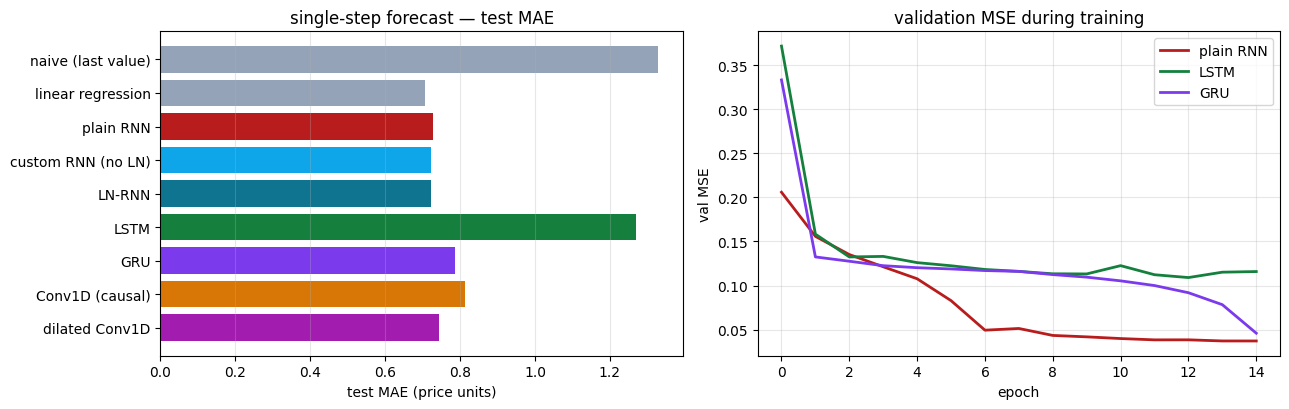

In [11]:
# bar chart of test MAE + learning-curve overlay
names = [n for n in order if n in scoreboard]
test_maes = [scoreboard[n][1] for n in names]
cols = ['#94a3b8', '#94a3b8', '#b91c1c', '#0ea5e9', '#0e7490',
        '#15803d', '#7c3aed', '#d97706', '#a21caf'][:len(names)]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
a1.barh(range(len(names)), test_maes, color=cols)
a1.set_yticks(range(len(names))); a1.set_yticklabels(names)
a1.invert_yaxis(); a1.set_xlabel('test MAE (price units)')
a1.set_title('single-step forecast — test MAE'); a1.grid(axis='x', alpha=0.3)

for n, c in [('plain RNN', '#b91c1c'), ('LSTM', '#15803d'), ('GRU', '#7c3aed')]:
    if n in curves:
        a2.plot(curves[n]['va'], label=n, color=c, lw=2)
a2.set_title('validation MSE during training'); a2.set_xlabel('epoch')
a2.set_ylabel('val MSE'); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Exercises

Pick **two** and report findings in 3–5 sentences each (plot if helpful):

1. **Forget-gate bias.** Re-train the LSTM with the forget-bias init **removed**. Does the
   early part of the learning curve change? Does final MAE?
2. **Hidden size.** Sweep `HIDDEN ∈ {8, 16, 32, 64}` for LSTM and GRU. Plot val MAE vs
   size. Where does each plateau, and does GRU stay competitive at every size?
3. **Receptive field.** Change the dilated model's `dilations` to `(1, 2, 4, 8, 16, 32)`.
   Print the new receptive field and see whether the longer reach helps on this series.
4. **Kernel vs dilation.** Match a *plain* (non-dilated) conv stack to the dilated model's
   receptive field by adding layers. Compare parameter counts and MAE — what did dilation buy?
5. **Multi-step.** Give the GRU a `nn.Linear(hidden, H)` head (seq-to-vec, `H=10`) and
   compare against an iterative one-step roll-out, reusing Lab 1's `MultiStepDataset`.

> **Bonus / discussion:** a **bidirectional** LSTM reads the sequence both ways and is
> excellent for *labeling* a finished sequence — but it needs the whole sequence up front,
> so it **cannot** be used for causal forecasting. Why would using it here leak the answer?

---
### Wrap-up

What you built, all on one dataset:

- a **LayerNorm** ablation inside a hand-rolled RNN cell,
- **LSTM** and **GRU** forecasters (gated memory, with the forget-bias trick),
- a **causal Conv1D** forecaster (channels-first + left padding),
- a **dilated** causal conv stack with residual connections and an exponential receptive field,
- a single **scoreboard** comparing all eight models head-to-head.

The throughline of the whole lecture: **every design is about controlling how information
and gradients flow through time** — gates do it by learning what to keep, convolutions do
it by fixing a receptive field and training in parallel.